# Fig6_cph.ipynb

## Introduction
This notebook focuses on calculating and comparing Spearman's correlation coefficients between distance from two types of centers (geographical center vs. ecological/niche center) and suitability values. It also fits Beta regression models to examine how suitability declines with increasing distance from these centers.


In [1]:
# Import necessary modules and functions.
# PlotUtlis, Beta, create_folder, mm2inch, set_mpl_defaults, logistic are imported from Utils.py.
# Additional libraries are used for I/O, data manipulation, and statistics.

from Utils import PlotUtlis, Beta, create_folder, mm2inch, set_mpl_defaults, logistic
import matplotlib.pyplot as plt
import numpy as np
import os
import json
import scipy

# Set default matplotlib parameters for uniform styling.
set_mpl_defaults()

### Specify run and experiment IDs

In [2]:
# Define the run_id and exp_id that will be used when creating a PlotUtlis instance.
run_id = '144fa175d5d1428cb9b434cd1a0024f8'
exp_id = '625518819310735286'

### Create the PlotUtlis object

In [3]:
# Instantiate PlotUtlis with the run and experiment IDs.
# This handles file paths and data loading for the subsequent analyses.
PU = PlotUtlis(run_id = run_id, exp_id = exp_id)

### Create output directory if needed

In [4]:
# Ensure the output directory for these plots exists.
create_folder(PU.plot_path_cph)

### Calculate Spearman's correlation (geographical center vs. niche center)

In [5]:
# Calculate Spearman's rho for each species based on geographic center and niche center.
# Also retrieves fitted parameters for Beta regression from both niche-based distances and geographic distances.
df_spearman_ecogeo, niche_beta_params, geographical_beta_params = PU.calculate_cph_spearman_beta()

/home/klok0126/.local/lib/python3.12/site-packages/statsmodels/tools/numdiff.py:157: RuntimeWarning: invalid value encountered in scalar subtract
  grad[k, :] = (f(*((x+ei,)+args), **kwargs) -
/home/klok0126/.local/lib/python3.12/site-packages/statsmodels/tools/numdiff.py:157: RuntimeWarning: invalid value encountered in scalar subtract
  grad[k, :] = (f(*((x+ei,)+args), **kwargs) -
/home/klok0126/.local/lib/python3.12/site-packages/statsmodels/tools/numdiff.py:157: RuntimeWarning: invalid value encountered in scalar subtract
  grad[k, :] = (f(*((x+ei,)+args), **kwargs) -
/home/klok0126/.local/lib/python3.12/site-packages/statsmodels/tools/numdiff.py:157: RuntimeWarning: invalid value encountered in scalar subtract
  grad[k, :] = (f(*((x+ei,)+args), **kwargs) -
/home/klok0126/.local/lib/python3.12/site-packages/statsmodels/tools/numdiff.py:157: RuntimeWarning: invalid value encountered in scalar subtract
  grad[k, :] = (f(*((x+ei,)+args), **kwargs) -
/home/klok0126/.local/lib/python3.1

### Save results for Spearman's correlation and Beta regression parameters

In [6]:
# Export the DataFrame of Spearman's correlation to CSV.
# Save the niche-based Beta regression parameters and the geographic-based Beta regression parameters in JSON.
df_spearman_ecogeo.to_csv(PU.df_spearman_ecogeo_path, index = None)
with open(PU.niche_beta_params_path, 'w') as f:
    json.dump(niche_beta_params, f, indent = 4)
with open(PU.geographical_beta_params_path, 'w') as f:
    json.dump(geographical_beta_params, f, indent = 4)

### Create histograms comparing Spearman's rho between two center types

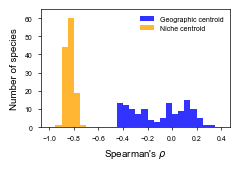

In [16]:
# Plot histograms of Spearman's rho comparing Geographical_center vs. Niche_center.
bin_width = 0.05
bins = np.arange(-1, 0.4 + bin_width, bin_width)

fig, ax = plt.subplots(
    figsize = mm2inch(60, 40), 
    gridspec_kw = {'left': 0.15, 'right': 0.95, 'bottom': 0.2, 'top': 0.95}
)
ax.hist(
    PU.df_spearman_ecogeo['rho'][PU.df_spearman_ecogeo.center_type == 'Geographical_center'],
    bins = bins,
    label = 'Geographic centroid',
    color = 'blue',
    alpha = 0.8
)
ax.hist(
    PU.df_spearman_ecogeo['rho'][PU.df_spearman_ecogeo.center_type == 'Niche_center'],
    bins = bins,
    label = 'Niche centroid',
    color = 'orange',
    alpha = 0.8
)

ax.legend(loc='upper right')
ax.set_xlabel("Spearman's $\\rho$")
ax.set_ylabel('Number of species')
ax.set_ylim(top = 65)

plot_output = os.path.join(PU.plot_path_cph, 'DeepSDM_rho_comparison_hist.pdf')
plt.savefig(plot_output, dpi = 500, transparent = True)
plt.show()

### Statistical tests (K-S test, Mann–Whitney U test) on Spearman's rho distributions

In [8]:
# Retrieve Spearman's rho values for Geographical_center and Niche_center.
rho_geo = PU.df_spearman_ecogeo.loc[
    PU.df_spearman_ecogeo.center_type == 'Geographical_center', 
    'rho'
].dropna()

rho_eco = PU.df_spearman_ecogeo.loc[
    PU.df_spearman_ecogeo.center_type == 'Niche_center', 
    'rho'
].dropna()

# Perform Kolmogorov–Smirnov test (KS test) to compare distributions.
ks_stat, ks_pvalue = scipy.stats.ks_2samp(rho_geo, rho_eco)
print("=== Kolmogorov–Smirnov (K-S) test ===")
print(f"K-S statistic = {ks_stat:.4f}")
print(f"K-S p-value   = {ks_pvalue:.4e}")

# Perform Mann–Whitney U test to compare the two sets of Spearman's rho.
mw_stat, mw_pvalue = scipy.stats.mannwhitneyu(rho_geo, rho_eco, alternative='two-sided')
print("=== Mann–Whitney U test ===")
print(f"U statistic   = {mw_stat:.4f}")
print(f"p-value       = {mw_pvalue:.4e}")

# Print descriptive statistics for completeness.
print("\n=== Descriptive statistics ===")
print("Geographical center (Spearman's rho):")
print(rho_geo.describe())
print("\nEcological center (Spearman's rho):")
print(rho_eco.describe())

=== Kolmogorov–Smirnov (K-S) test ===
K-S statistic = 1.0000
K-S p-value   = 2.1928e-74
=== Mann–Whitney U test ===
U statistic   = 15625.0000
p-value       = 1.6456e-42

=== Descriptive statistics ===
Geographical center (Spearman's rho):
count    125.000000
mean      -0.104189
std        0.219184
min       -0.444506
25%       -0.318381
50%       -0.061437
75%        0.104884
max        0.310164
Name: rho, dtype: float64

Ecological center (Spearman's rho):
count    125.000000
mean      -0.836655
std        0.032285
min       -0.903667
25%       -0.858804
50%       -0.837343
75%       -0.815145
max       -0.748253
Name: rho, dtype: float64


### Perform Beta regression using all pixels within clusters

In [5]:
# Apply Beta regression in a cluster-wise manner.
species_exclude = ['Tyto_longimembris', 'Synoicus_chinensis', 'Turnix_sylvaticus', 'Ketupa_flavipes']
niche_beta_cluster_params, geographical_beta_cluster_params = PU.calculate_cph_spearman_beta_cluster(species_exclude = species_exclude)

1
<class 'numpy.str_'>
['Acridotheres_cristatellus' 'Alauda_gulgula' 'Amaurornis_phoenicurus'
 'Apus_nipalensis' 'Caprimulgus_affinis' 'Cecropis_striolata'
 'Centropus_bengalensis' 'Cisticola_exilis' 'Cisticola_juncidis'
 'Egretta_sacra' 'Elanus_caeruleus' 'Gallinula_chloropus'
 'Gallirallus_striatus' 'Hirundo_tahitica' 'Ixobrychus_cinnamomeus'
 'Lanius_schach' 'Lonchura_atricapilla' 'Lonchura_punctulata'
 'Passer_montanus' 'Porzana_fusca' 'Prinia_flaviventris' 'Prinia_inornata'
 'Pycnonotus_sinensis' 'Riparia_chinensis' 'Rostratula_benghalensis'
 'Sinosuthora_webbiana' 'Spilopelia_chinensis'
 'Streptopelia_tranquebarica' 'Turnix_suscitator' 'Zosterops_simplex']


/home/klok0126/.local/lib/python3.12/site-packages/statsmodels/tools/numdiff.py:157: RuntimeWarning: invalid value encountered in scalar subtract
  grad[k, :] = (f(*((x+ei,)+args), **kwargs) -


2
<class 'numpy.str_'>
['Actinodura_morrisoniana' 'Brachypteryx_goodfellowi'
 'Carpodacus_formosanus' 'Dendrocopos_leucotos' 'Fulvetta_formosana'
 'Horornis_acanthizoides' 'Locustella_alishanensis'
 'Nucifraga_caryocatactes' 'Periparus_ater' 'Picus_canus'
 'Pnoepyga_formosana' 'Prunella_collaris' 'Pyrrhula_nipalensis'
 'Pyrrhula_owstoni' 'Regulus_goodfellowi' 'Sitta_europaea'
 'Strix_leptogrammica' 'Strix_nivicolum' 'Suthora_verreauxi'
 'Syrmaticus_mikado' 'Tarsiger_indicus' 'Tarsiger_johnstoniae'
 'Trochalopteron_morrisonianum' 'Troglodytes_troglodytes' 'Zoothera_dauma']


/home/klok0126/.local/lib/python3.12/site-packages/statsmodels/tools/numdiff.py:157: RuntimeWarning: invalid value encountered in scalar subtract
  grad[k, :] = (f(*((x+ei,)+args), **kwargs) -


3
<class 'numpy.str_'>
['Abroscopus_albogularis' 'Accipiter_trivirgatus' 'Accipiter_virgatus'
 'Aegithalos_concinnus' 'Alcippe_brunnea' 'Alcippe_morrisonia'
 'Arborophila_crudigularis' 'Bambusicola_sonorivox' 'Chalcophaps_indica'
 'Cinclus_pallasii' 'Columba_pulchricollis' 'Coracina_macei'
 'Corvus_macrorhynchos' 'Delichon_dasypus' 'Dendrocitta_formosae'
 'Dicaeum_ignipectus' 'Dicaeum_minullum' 'Dicrurus_aeneus'
 'Enicurus_scouleri' 'Erpornis_zantholeuca' 'Ficedula_hyperythra'
 'Garrulax_poecilorhynchus' 'Garrulax_ruficeps' 'Garrulax_taewanus'
 'Garrulus_glandarius' 'Glaucidium_brodiei' 'Gorsachius_melanolophus'
 'Heterophasia_auricularis' 'Hirundapus_cochinchinensis'
 'Horornis_fortipes' 'Hypothymis_azurea' 'Hypsipetes_leucocephalus'
 'Ictinaetus_malayensis' 'Liocichla_steerii' 'Lonchura_striata'
 'Lophura_swinhoii' 'Myiomela_leucura' 'Myophonus_insularis'
 'Niltava_vivida' 'Nisaetus_nipalensis' 'Oriolus_traillii' 'Otus_lettia'
 'Otus_spilocephalus' 'Parus_holsti' 'Parus_monticolus'
 

/home/klok0126/.local/lib/python3.12/site-packages/statsmodels/tools/numdiff.py:157: RuntimeWarning: invalid value encountered in scalar subtract
  grad[k, :] = (f(*((x+ei,)+args), **kwargs) -


### Save the cluster-based Beta regression parameters

In [7]:
# Write the Beta regression results (cluster-based) for niche and geographical centers.
with open(PU.niche_beta_cluster_params_path, 'w') as f:
    json.dump(niche_beta_cluster_params, f, indent = 4)
with open(PU.geographical_beta_cluster_params_path, 'w') as f:
    json.dump(geographical_beta_cluster_params, f, indent = 4)

### Plot Beta regression lines for individual species (geographical center)

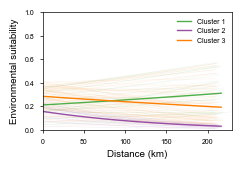

In [10]:
# This block plots regression lines for each species with respect to geographic distance.
# It also plots averaged lines for each cluster.

fig, ax = plt.subplots(
    figsize = mm2inch(60, 40), 
    gridspec_kw = {'left': 0.15, 'right': 0.95, 'bottom': 0.2, 'top': 0.95}
)
max_x_overall = 0.0
for i, species in enumerate(PU.species_list_exclude):
    info = PU.geographical_beta_params[species]
    params_mu = np.array(info["params_mu"])
    x_min = info["x_min"]
    x_max = info["x_max"]
    y_min = info["y_min"]
    y_max = info["y_max"]
    eps   = info["epsilon"]

    if x_max > max_x_overall:
        max_x_overall = x_max

    x_line = np.linspace(x_min, x_max, 100)
    X_line = np.column_stack([np.ones_like(x_line), x_line])
    linear_pred = X_line @ params_mu
    mu_pred_norm = logistic(linear_pred)
    mu_pred = ((mu_pred_norm - eps) / (1 - 2*eps)) * (y_max - y_min) + y_min

    cluster_idx = PU.cluster_labels[i]
    ax.plot(x_line, mu_pred, color=PU.label_to_color[str(cluster_idx)], alpha=0.1, linewidth=0.3)

# Plot the average Beta regression line for each cluster.
x_min_cluster = max([p['x_min'] for p in PU.geographical_beta_cluster_params.values()])
x_max_cluster = min([p['x_max'] for p in PU.geographical_beta_cluster_params.values()])

for i, lbl in enumerate(PU.label_to_color.keys()):
    info = PU.geographical_beta_cluster_params[lbl]    
    params_mu = np.array(info["params_mu"])
    phi = np.array(info["params_phi"])
    x_min = info["x_min"]
    x_max = info["x_max"]
    y_min = info["y_min"]
    y_max = info["y_max"]
    eps   = info["epsilon"]    

    x_line = np.linspace(x_min_cluster, x_max_cluster)
    X_line = np.column_stack([np.ones_like(x_line), x_line])
    linear_pred = X_line @ params_mu
    mu_pred_norm = logistic(linear_pred)
    mu_pred = ((mu_pred_norm - eps) / (1 - 2*eps)) * (y_max - y_min) + y_min

    ax.plot(
        x_line, mu_pred,
        color=PU.label_to_color[lbl],
        alpha=1.0,
        linewidth=1,
        label=f'Cluster {lbl}'
    )

ax.set_ylim(bottom=0, top=1)
ax.set_xlim(left=0, right=max_x_overall)
ax.set_ylabel('Environmental suitability')
ax.set_xlabel('Distance (km)')
ax.legend(loc='best')

plot_output = os.path.join(PU.plot_path_cph, 'geo_beta_reg.pdf')
plt.savefig(plot_output, dpi=500, transparent=True)
plt.show()

### Plot Beta regression lines for individual species (niche center)

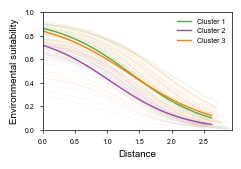

In [11]:
# This block creates plots for each species' Beta regression result with respect to niche-based (ecological) distance.
# It also plots the average niche-based Beta regression lines for each cluster.

fig, ax = plt.subplots(
    figsize=mm2inch(60, 40), 
    gridspec_kw={'left': 0.15, 'right': 0.95, 'bottom': 0.2, 'top': 0.95}
)
max_x_overall = 0.0
for i, species in enumerate(PU.species_list_exclude):
    info = PU.niche_beta_params[species]
    params_mu = np.array(info["params_mu"])
    x_min = info["x_min"]
    x_max = info["x_max"]
    y_min = info["y_min"]
    y_max = info["y_max"]
    eps   = info["epsilon"]

    if x_max > max_x_overall:
        max_x_overall = x_max

    x_line = np.linspace(x_min, x_max, 100)
    X_line = np.column_stack([np.ones_like(x_line), x_line])
    linear_pred = X_line @ params_mu
    mu_pred_norm = logistic(linear_pred)
    mu_pred = ((mu_pred_norm - eps) / (1 - 2*eps)) * (y_max - y_min) + y_min

    cluster_idx = PU.cluster_labels[i]
    ax.plot(x_line, mu_pred, color=PU.label_to_color[str(cluster_idx)], alpha=0.1, linewidth=0.3)

x_min_cluster = max([p['x_min'] for p in PU.niche_beta_cluster_params.values()])
x_max_cluster = min([p['x_max'] for p in PU.niche_beta_cluster_params.values()])

for i, lbl in enumerate(PU.label_to_color.keys()):
    info = PU.niche_beta_cluster_params[lbl]
    params_mu = np.array(info["params_mu"])
    phi = np.array(info["params_phi"])
    x_min = info["x_min"]
    x_max = info["x_max"]
    y_min = info["y_min"]
    y_max = info["y_max"]
    eps   = info["epsilon"]

    x_line = np.linspace(x_min_cluster, x_max_cluster)
    X_line = np.column_stack([np.ones_like(x_line), x_line])
    linear_pred = X_line @ params_mu
    mu_pred_norm = logistic(linear_pred)
    mu_pred = ((mu_pred_norm - eps) / (1 - 2*eps)) * (y_max - y_min) + y_min

    ax.plot(
        x_line,
        mu_pred,
        color=PU.label_to_color[lbl],
        alpha=1.0,
        linewidth=1,
        label=f'Cluster {lbl}'
    )

ax.set_ylim(bottom=0, top=1)
ax.set_xlim(left=0, right=max_x_overall)
ax.set_ylabel('Environmental suitability')
ax.set_xlabel('Distance')
ax.legend(loc='best')

plot_output = os.path.join(PU.plot_path_cph, 'niche_beta_reg.pdf')
plt.savefig(plot_output, dpi=500, transparent=True)
plt.show()

### Generate individual subplot figures for selected species

In [5]:
# Specify a few target species whose results are to be plotted individually.
species_to_print = [
    'Yuhina_brunneiceps', 
    'Psilopogon_nuchalis', 
    'Locustella_alishanensis', 
    'Gallinula_chloropus', 
    'Treron_formosae', 
    'Phasianus_colchicus', 
    'Pycnonotus_taivanus'
]

### Plot detailed subplots for selected species

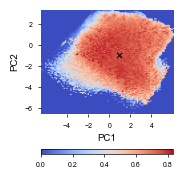

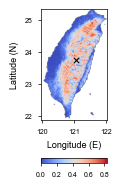

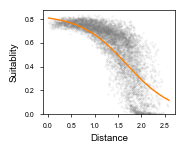

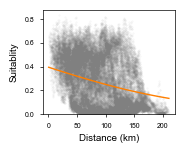

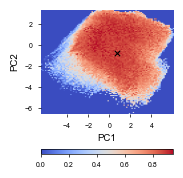

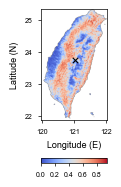

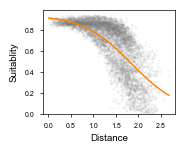

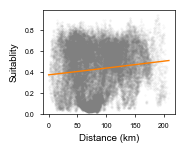

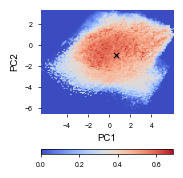

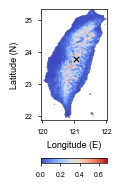

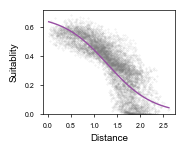

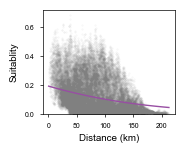

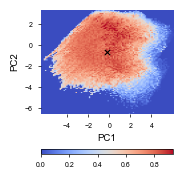

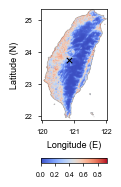

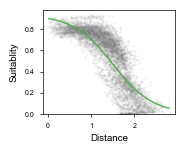

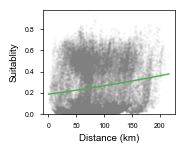

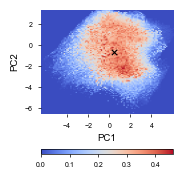

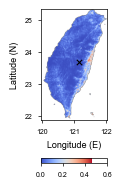

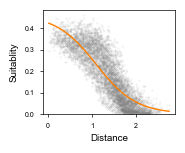

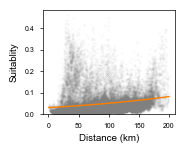

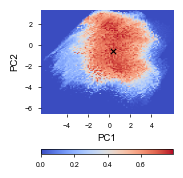

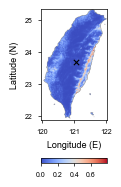

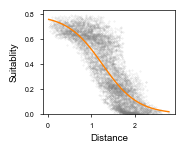

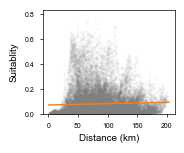

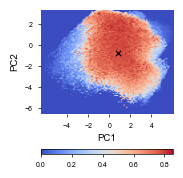

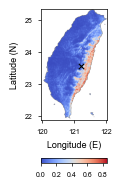

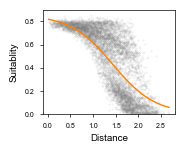

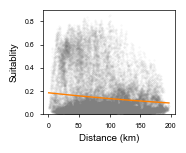

In [6]:
# Call a utility function to generate and save subplot figures for the chosen species.
species_exclude = ['Tyto_longimembris', 'Synoicus_chinensis', 'Turnix_sylvaticus', 'Ketupa_flavipes']
PU.plot_subplots(species_to_print, species_exclude = species_exclude)